# TP1 — Un modelo por cada interacción posible

Este notebook evalúa un modelo lineal base y **36 modelos adicionales**, uno por cada interacción posible entre las 9 variables del TP. Todos se comparan usando exactamente las mismas particiones de validación cruzada de 5 folds.

Para cada modelo se guardan MAE y R² en cada fold, sus promedios y desvíos, y la diferencia respecto del modelo base. Un MAE menor y un R² mayor indican una mejora.

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)
RANDOM_STATE = 42
N_FOLDS = 5

## 1. Carga y preparación

Las variables categóricas se convierten a 0/1. La codificación es fija y no usa información de `weight`.

In [2]:
# Funciona tanto al ejecutar desde esta carpeta como desde otra ubicación.
carpeta = Path.cwd()
if not (carpeta / 'X_train.csv').exists():
    carpeta = Path('LdD2026 modificacion/TPs/TP1')

X_original = pd.read_csv(carpeta / 'X_train.csv')
y_original = pd.read_csv(carpeta / 'y_train.csv')['weight']

X = pd.DataFrame({
    'fage': X_original['fage'],
    'mage': X_original['mage'],
    'visits': X_original['visits'],
    'gained': X_original['gained'],
    'sex_bin': X_original['sex'].map({'female': 0, 'male': 1}),
    'habit_bin': X_original['habit'].map({'nonsmoker': 0, 'smoker': 1}),
    'marital_bin': X_original['marital'].map({'not married': 0, 'married': 1}),
    'whitemom_bin': X_original['whitemom'].map({'not white': 0, 'white': 1}),
    'mature_bin': X_original['mature'].map({'younger mom': 0, 'mature mom': 1}),
})

assert len(X) == len(y_original), 'X e y deben tener la misma cantidad de filas'
assert np.isfinite(X.to_numpy()).all(), 'Revisar categorías o faltantes: no descartar filas silenciosamente'
assert np.isfinite(y_original.to_numpy()).all(), 'Hay valores faltantes o no finitos en weight'
datos = X.assign(weight=y_original).reset_index(drop=True)
X = datos.drop(columns='weight')
y = datos['weight']

print(f'Observaciones utilizadas: {len(X)}')
print(f'Variables base: {X.shape[1]}')
print(f'Interacciones posibles: {len(list(combinations(X.columns, 2)))}')
X.head()

Observaciones utilizadas: 675
Variables base: 9
Interacciones posibles: 36


,fage,mage,visits,gained,sex_bin,habit_bin,marital_bin,whitemom_bin,mature_bin
0,34.0,34,14.0,28.0,1,0,1,1,0
1,36.0,31,12.0,41.0,0,0,1,1,0
2,37.0,36,10.0,28.0,0,0,1,0,1
3,32.0,31,12.0,48.0,0,0,1,1,0
4,32.0,26,14.0,45.0,0,0,1,1,0


## 2. Evaluación con los mismos 5 folds

Cada modelo de interacción conserva las 9 variables base y agrega un solo producto `variable_1 × variable_2`. Esto permite atribuir la diferencia de desempeño a esa interacción.

In [3]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
particiones = list(kf.split(X))  # se reutilizan para todos los modelos
pares = list(combinations(X.columns, 2))
resultados_fold = []

def evaluar_modelo(nombre, X_modelo, var_1=None, var_2=None):
    for fold, (idx_train, idx_valid) in enumerate(particiones, start=1):
        X_train_fold = X_modelo.iloc[idx_train]
        X_valid_fold = X_modelo.iloc[idx_valid]
        y_train_fold = y.iloc[idx_train]
        y_valid_fold = y.iloc[idx_valid]

        modelo = LinearRegression()
        modelo.fit(X_train_fold, y_train_fold)
        pred = modelo.predict(X_valid_fold)

        resultados_fold.append({
            'modelo': nombre,
            'variable_1': var_1,
            'variable_2': var_2,
            'fold': fold,
            'n_train': len(idx_train),
            'n_validacion': len(idx_valid),
            'mae': mean_absolute_error(y_valid_fold, pred),
            'r2': r2_score(y_valid_fold, pred),
        })

# Referencia sin interacciones
evaluar_modelo('BASE (sin interacción)', X)

# Un modelo nuevo por cada par posible
for var_1, var_2 in pares:
    nombre_interaccion = f'{var_1} × {var_2}'
    X_interaccion = X.assign(**{nombre_interaccion: X[var_1] * X[var_2]})
    evaluar_modelo(nombre_interaccion, X_interaccion, var_1, var_2)

resultados_fold = pd.DataFrame(resultados_fold)
print(f'Modelos evaluados: {resultados_fold.modelo.nunique()}')
print(f'Ajustes realizados: {len(resultados_fold)}')
resultados_fold.head(10)

Modelos evaluados: 37
Ajustes realizados: 185


,modelo,variable_1,variable_2,fold,n_train,n_validacion,mae,r2
0,BASE (sin interacción),NaN,NaN,1,540,135,0.857530,-0.031743
1,BASE (sin interacción),NaN,NaN,2,540,135,0.881202,0.074449
2,BASE (sin interacción),NaN,NaN,3,540,135,0.931263,-0.004558
3,BASE (sin interacción),NaN,NaN,4,540,135,0.933166,0.094346
4,BASE (sin interacción),NaN,NaN,5,540,135,0.896456,0.030543
5,fage × mage,fage,mage,1,540,135,0.858780,-0.040694
6,fage × mage,fage,mage,2,540,135,0.884727,0.073007
7,fage × mage,fage,mage,3,540,135,0.933022,-0.006124
8,fage × mage,fage,mage,4,540,135,0.933340,0.093974
9,fage × mage,fage,mage,5,540,135,0.896565,0.031703


## 3. Resumen y comparación con el modelo base

In [4]:
resumen = (
    resultados_fold
    .groupby(['modelo', 'variable_1', 'variable_2'], dropna=False)
    .agg(
        mae_promedio=('mae', 'mean'),
        mae_desvio=('mae', 'std'),
        r2_promedio=('r2', 'mean'),
        r2_desvio=('r2', 'std'),
    )
    .reset_index()
)

base = resumen.loc[resumen['modelo'] == 'BASE (sin interacción)'].iloc[0]
resumen['diferencia_mae_vs_base'] = resumen['mae_promedio'] - base['mae_promedio']
resumen['diferencia_r2_vs_base'] = resumen['r2_promedio'] - base['r2_promedio']
resumen['mejora_ambas_metricas'] = (
    (resumen['diferencia_mae_vs_base'] < -1e-10)
    & (resumen['diferencia_r2_vs_base'] > 1e-10)
)
resumen = resumen.sort_values(['mae_promedio', 'r2_promedio'], ascending=[True, False]).reset_index(drop=True)
resumen.insert(0, 'ranking_mae', np.arange(1, len(resumen) + 1))

columnas_vista = [
    'ranking_mae', 'modelo', 'mae_promedio', 'mae_desvio',
    'r2_promedio', 'r2_desvio', 'diferencia_mae_vs_base',
    'diferencia_r2_vs_base', 'mejora_ambas_metricas'
]
resumen[columnas_vista].round(4)

,ranking_mae,modelo,mae_promedio,mae_desvio,r2_promedio,r2_desvio,diferencia_mae_vs_base,diferencia_r2_vs_base,mejora_ambas_metricas
0,1,mage × visits,0.8947,0.0355,0.0387,0.0665,-0.0052,0.0060,True
1,2,fage × visits,0.8959,0.0333,0.0351,0.0612,-0.0040,0.0025,True
2,3,visits × mature_bin,0.8966,0.0360,0.0401,0.0501,-0.0033,0.0075,True
3,4,sex_bin × marital_bin,0.8978,0.0307,0.0364,0.0502,-0.0022,0.0038,True
4,5,marital_bin × whitemom_bin,0.8984,0.0339,0.0350,0.0622,-0.0016,0.0024,True
5,6,fage × gained,0.8994,0.0321,0.0322,0.0545,-0.0005,-0.0004,False
6,7,fage × marital_bin,0.8998,0.0326,0.0320,0.0512,-0.0001,-0.0006,False
7,8,BASE (sin interacción),0.8999,0.0326,0.0326,0.0527,0.0000,0.0000,False
8,9,habit_bin × mature_bin,0.8999,0.0326,0.0326,0.0527,0.0000,0.0000,False
9,10,mage × marital_bin,0.9001,0.0324,0.0318,0.0521,0.0001,-0.0008,False


## 4. Guardado de resultados

Se guardan dos archivos: uno con las 185 evaluaciones individuales (37 modelos × 5 folds) y otro con el resumen por modelo.

In [5]:
archivo_folds = carpeta / 'resultados_interacciones_por_fold.csv'
archivo_resumen = carpeta / 'resultados_interacciones_resumen.csv'

resultados_fold.to_csv(archivo_folds, index=False)
resumen.to_csv(archivo_resumen, index=False)

print(f'Guardado: {archivo_folds.resolve()}')
print(f'Guardado: {archivo_resumen.resolve()}')

Guardado: G:\My Drive\W\2026-2C-Labo-de-datos\LdD2026 modificacion\TPs\TP1\resultados_interacciones_por_fold.csv
Guardado: G:\My Drive\W\2026-2C-Labo-de-datos\LdD2026 modificacion\TPs\TP1\resultados_interacciones_resumen.csv


## 5. Visualización de la comparación

El punto rojo es el modelo base. Los puntos verdes son interacciones que mejoran simultáneamente el MAE y el R² promedio.

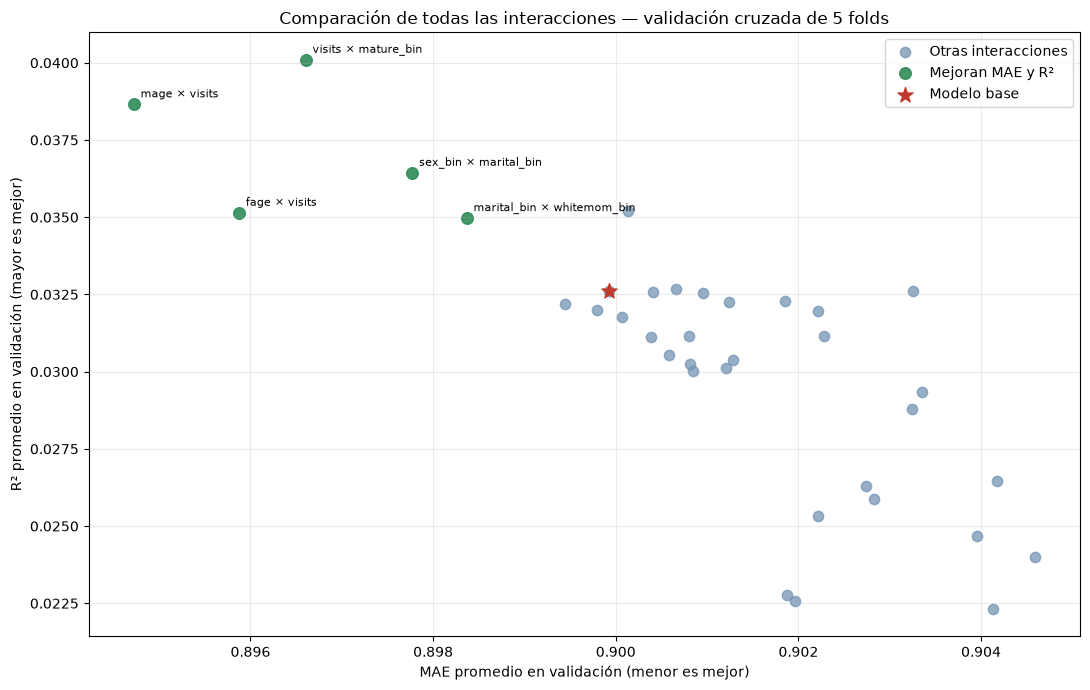

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))
es_base = resumen['modelo'].eq('BASE (sin interacción)')
mejora = resumen['mejora_ambas_metricas'] & ~es_base
resto = ~es_base & ~mejora

ax.scatter(resumen.loc[resto, 'mae_promedio'], resumen.loc[resto, 'r2_promedio'],
           color='#7393B3', alpha=0.75, s=55, label='Otras interacciones')
ax.scatter(resumen.loc[mejora, 'mae_promedio'], resumen.loc[mejora, 'r2_promedio'],
           color='#2E8B57', alpha=0.9, s=70, label='Mejoran MAE y R²')
ax.scatter(base['mae_promedio'], base['r2_promedio'], color='#C0392B', s=130,
           marker='*', label='Modelo base', zorder=5)

for _, fila in resumen.head(5).iterrows():
    ax.annotate(fila['modelo'], (fila['mae_promedio'], fila['r2_promedio']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('MAE promedio en validación (menor es mejor)')
ax.set_ylabel('R² promedio en validación (mayor es mejor)')
ax.set_title('Comparación de todas las interacciones — validación cruzada de 5 folds')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Mejores interacciones

Esta tabla final muestra las diez mejores por MAE. Conviene mirar también el desvío entre folds: una diferencia promedio muy pequeña frente a un desvío grande no es evidencia sólida de mejora.

In [7]:
top_10 = resumen.loc[resumen['modelo'] != 'BASE (sin interacción)', columnas_vista].head(10)
print(f"MAE base: {base['mae_promedio']:.4f} ± {base['mae_desvio']:.4f}")
print(f"R² base:  {base['r2_promedio']:.4f} ± {base['r2_desvio']:.4f}")
print(f"Interacciones que mejoran ambas métricas: {int(resumen['mejora_ambas_metricas'].sum())}")
top_10.round(4)

MAE base: 0.8999 ± 0.0326
R² base:  0.0326 ± 0.0527
Interacciones que mejoran ambas métricas: 5


,ranking_mae,modelo,mae_promedio,mae_desvio,r2_promedio,r2_desvio,diferencia_mae_vs_base,diferencia_r2_vs_base,mejora_ambas_metricas
0,1,mage × visits,0.8947,0.0355,0.0387,0.0665,-0.0052,0.0060,True
1,2,fage × visits,0.8959,0.0333,0.0351,0.0612,-0.0040,0.0025,True
2,3,visits × mature_bin,0.8966,0.0360,0.0401,0.0501,-0.0033,0.0075,True
3,4,sex_bin × marital_bin,0.8978,0.0307,0.0364,0.0502,-0.0022,0.0038,True
4,5,marital_bin × whitemom_bin,0.8984,0.0339,0.0350,0.0622,-0.0016,0.0024,True
5,6,fage × gained,0.8994,0.0321,0.0322,0.0545,-0.0005,-0.0004,False
6,7,fage × marital_bin,0.8998,0.0326,0.0320,0.0512,-0.0001,-0.0006,False
8,9,habit_bin × mature_bin,0.8999,0.0326,0.0326,0.0527,0.0000,0.0000,False
9,10,mage × marital_bin,0.9001,0.0324,0.0318,0.0521,0.0001,-0.0008,False
10,11,gained × habit_bin,0.9001,0.0326,0.0352,0.0572,0.0002,0.0026,False
